# Voxel-wise Permutation Testing demo

## Data simulation 

We simulate a null fMRI dataset with no true activation.  
For each subject ( i = 1, ... , n ), we generate a 2-D image Yi(x, y)  of size S*S (Currently S = 64) voxels.

### 1. Noise generation

Each voxel is drawn independently from a normal distribution:

$$
Y_i(x, y) \sim \mathrm{Normal}(0, 1).
$$


### 2. Smoothing

To introduce spatial correlation, each image is convolved with a 
Gaussian smoothing kernel.

### 3. Final dataset

The simulated null dataset is:

$$
\{\, Y_i^{\text{smooth}}(x,y) \;:\; i=1,\dots,n \,\}
$$

with no true activation anywhere in the image.

# Models Used:

# One sample model (no labels)

Each voxel has observations:

$$
y = (y_1, y_2, \ldots, y_n)^\top.
$$

The design matrix is

$$
X =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix}
\quad (n \times 1).
$$

The model is:

$$
y = X\beta + \varepsilon,
$$

where

- $\beta$ is the mean activation,  
- $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.


The null hypothesis is

$$
H_0: \beta(v) = 0,
$$

that is, the mean signal at voxel \(v\) is zero.


The alternative hypothesis is

$$
H_1: \beta(v) \neq 0.
$$



### Contrast

$$
L = [1].
$$

### t statistic

$$
t(v) = \frac{L^\top \hat{\beta}(v)}{\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

# Two sample model (with labels)

Let the subjects be in two equal groups.

The design matrix is

$$
X =
\begin{bmatrix}
1 & 0 \\
\vdots & \vdots \\
1 & 0 \\
0 & 1 \\
\vdots & \vdots \\
0 & 1
\end{bmatrix}
\quad (n \times 2).
$$

The model:

$$
y = X\beta + \varepsilon,
$$

with

$$
\beta =
\begin{bmatrix}
\mu_1 \\
\mu_2
\end{bmatrix},
\qquad
\varepsilon \sim \mathcal{N}(0, \sigma^2 I).
$$

### Contrast

$$
L = [\,1,\ -1\,].
$$

Tests:

$$
H_0:\ \mu_1 - \mu_2 = 0.
$$

### t statistic

$$
t(v) = 
\frac{L^\top \hat{\beta}(v)}
     {\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

## Permutation Methods

### One sample (sign flipping)

Under the null:

$$
y_i^{new} = s_i\, y_i, \qquad s_i \in \{-1, +1\}.
$$

Each subject's sign is flipped independently with a 50:50 chance.


### Two sample (label shuffling)

Under the null, labels are exchangeable:

$$
X^{new} = \text{random permutation of rows of } X.
$$

This keeps the same number of subjects per group.


### Distribution of max T value

For each permutation

$$
m_p = \max_v \bigl|t_p(v)\bigr|.
$$


### Permutation threshold

$$
t_{\text{thr}} = \text{quantile}_{1-\alpha}(m_1,\dots,m_P).
$$


### Corrected significance map

$$
\text{sig}(v) = \mathbf{1}\{\,|t_{\text{real}}(v)| > t_{\text{thr}}\,\}.
$$

# FWER code demo

Import the helper function library

In [1]:
import helper_functions as hf
import plotters as pl
import importlib

Initialise the parameters

In [2]:
n_runs = 50		# Number of simulation runs for FWER estimation
n_subj = 20  			# Number of subjects in each group
img_side_length = 64    # Side length of the square brain image in voxels
smoothing_sigma = 1.5 	# Standard deviation for Gaussian smoothing
alpha = 0.05      		# Significance level for FWER
n_perm = 200		    # Number of permutations for permutation test
null_boundary = 1e-3   # Boundary value for null hypothesis in visualization

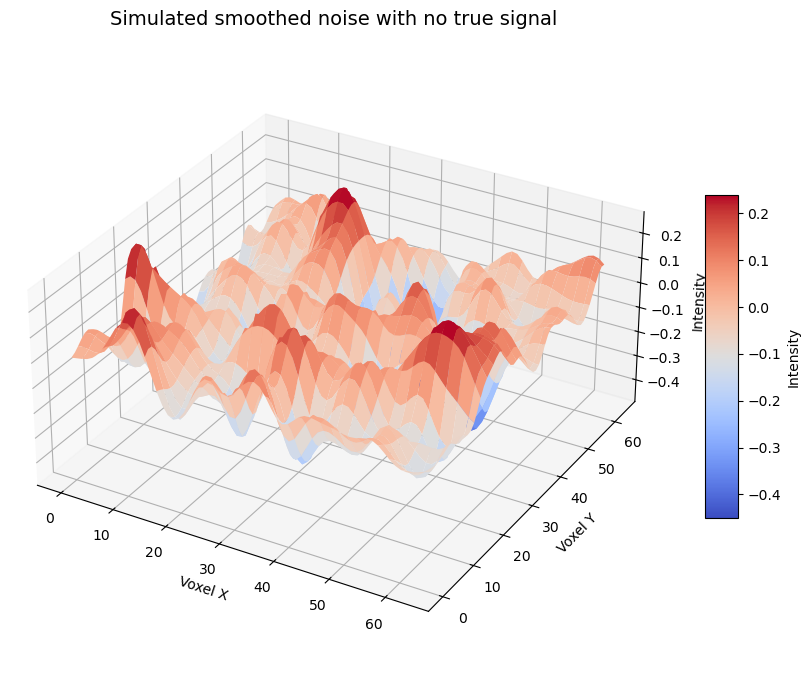

In [3]:
pl.plot_3d(hf.simulate_null_data(sigma = 2.5)[0], title="Simulated smoothed noise with no true signal")

Run the simulations and check the FWER error rate with no permutation correction applied

No labels (just 1 regressor in beta):

In [8]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=False
)

print(fwer_false_pos_rate)

1.0


With A/B labels (2 regressors in beta):

In [9]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=True
)

print(fwer_false_pos_rate)

1.0


In both cases, FWER is 1, which is very high, as expected.

## Clusterwise RFT Setup

In [10]:
import importlib
importlib.reload(hf)
import numpy as np
import pandas as pd
import helper_functions as hf

In [ ]:
def generate_data_and_tmap(n_subj=20, img_side=64, sigma=1.5, snr=0,
                           signal_radius=0, labels=False, return_all=False):
   
    data = hf.simulate_null_data(n_subj=n_subj,img_side=img_side,
                             sigma=sigma,snr=snr,signal_radius=signal_radius)
    X, L, df = hf.build_design_matrix(n_subj, labels=labels)
    beta = hf.compute_beta_map(data, X)
    variance,res = hf.compute_variance_and_residual_map(data, X, beta)
    tmap = hf.compute_t_map(beta, X, L, variance)

    if return_all:
        return {'data': data,'tmap': tmap,
            'beta': beta,'variance': variance,'X': X,'L': L,'df': df}
    else:
        return tmap


In [12]:
def test_rft_performance(n_sims, sigma, threshold_u, snr, 
                         n_subj=20, img_side=64, signal_radius=6, 
                         alpha=0.05, null_boundary=1e-3):

    true_mask = hf.get_smoothed_truth_mask(img_side, img_side, sigma, 
                                           signal_radius, null_boundary)
    noise_mask = ~true_mask
    total_signal_voxels = np.sum(true_mask)
    
    fwer_events = 0
    sensitivities = []
    
    for sim in range(n_sims):
        # Generate data and run RFT test
        tmap = generate_data_and_tmap(n_subj=n_subj, img_side=img_side,
                                          sigma=sigma, snr=snr, 
                                          signal_radius=signal_radius)
        
        sig_map, _, _, _, _ = hf.rft_clusterwise_test(
            tmap, sigma=sigma, threshold=threshold_u, fwer_alpha=alpha
        )
        
        true_pos = np.sum(sig_map & true_mask)
        sens = true_pos / total_signal_voxels if total_signal_voxels > 0 else 0
        sensitivities.append(sens)
        
        false_pos = np.sum(sig_map & noise_mask)
        if false_pos > 0:
            fwer_events += 1
    
    return {
        'fwer': fwer_events / n_sims,
        'sensitivity_mean': np.mean(sensitivities),
        'sensitivity_std': np.std(sensitivities)
    }






In [13]:
tmap = generate_data_and_tmap(n_subj=20, img_side=64, sigma=1.5, snr=2.5, signal_radius=6)
threshold_u = 3
alpha = 0.05

sig_map, cluster_pvals, k_c, labeled, sizes = hf.rft_clusterwise_test(
    tmap, sigma=1.5, threshold=threshold_u, fwer_alpha=alpha)

max_cluster_id = max(sizes, key=sizes.get) if len(sizes) > 0 else None
max_cluster_size = sizes[max_cluster_id] if max_cluster_id else 0

print(f"Critical cluster size (k_c): {k_c:.1f} voxels")
print(f"Detected clusters: {len(sizes)}")
print(f"Max cluster: Cluster {max_cluster_id} with {max_cluster_size} voxels")
print(f"Significant clusters: {len(cluster_pvals)}")

print(f"{'ID':<6} {'Size':<8} {'P-value':<12}")
for cid, size in sizes.items():
    # Compute p-value for ALL clusters (informational only)
    p_val = hf.compute_cluster_p_value(size, 
                                       hf.compute_expected_clusters(4096, 1.5*np.sqrt(2), threshold_u, 2),
                                       hf.cal_beta_parameter(
                                           hf.compute_expected_clusters(4096, 1.5*np.sqrt(2), threshold_u, 2),
                                           hf.cal_exp_voxels_above_threshold(4096, threshold_u), 2), 2)
    
    tested = "✓" if cid in cluster_pvals else ""
    print(f"{cid:<6} {size:<8} {p_val:.4f}")

AttributeError: module 'helper_functions' has no attribute 'compute_variance_map'

204.8

In [153]:
"""Fixed Variable"""
img_side = 64
signal_radius = 6
alpha = 0.05

"""Controlled Variable"""
n_subj = 20              # subject
sigma = 1.5              # smoothness
snr = 2.5
threshold_u = 2.5
null_boundary = 1e-3     # need debate for this value

true_mask = hf.get_smoothed_truth_mask(img_side, img_side, sigma, signal_radius, null_boundary)
noise_mask = ~true_mask

tmap = generate_data_and_tmap(n_subj=n_subj, img_side=img_side, 
                                  sigma=sigma, snr=snr, signal_radius=signal_radius)
sig_map, cluster_pvals, k_c, labeled, sizes = hf.rft_clusterwise_test(
    tmap, sigma=sigma, threshold=threshold_u, fwer_alpha=alpha)

max_cluster_id = max(sizes, key=sizes.get) if len(sizes) > 0 else None
max_cluster_size = sizes[max_cluster_id] if max_cluster_id else 0

true_positives = np.sum(sig_map & true_mask)
total_signal_voxels = np.sum(true_mask)
sensitivity = true_positives / total_signal_voxels if total_signal_voxels > 0 else 0
false_positives = np.sum(sig_map & noise_mask)
fwer_event = 1 if false_positives > 0 else 0

print(f"Parameters")
print(f"  Threshold (u): {threshold_u}")
print(f"  alpha_target: {alpha}")
print(f"  crit cluster size: {k_c:.1f} voxels")
print(f"  threshold: {threshold_u:.1f}")
print(f"  smoothness in terms of sigma: {sigma:.1f}")

print("--------------")


print("Clusterwise RFT results:")
print(f"Ground Truth")
print(f"Signal region {np.sum(true_mask)} voxels")
print(f"Noise region  {np.sum(noise_mask)} voxels")

# Cluster Detection
print(f"tot clusters detected: {len(sizes)}")
print(f"max cluster:  {max_cluster_id} ({max_cluster_size} voxels)")




Parameters
  Threshold (u): 2.5
  alpha_target: 0.05
  crit cluster size: 19.3 voxels
  threshold: 2.5
  smoothness in terms of sigma: 1.5
--------------
Clusterwise RFT results:
Ground Truth
Signal region 341 voxels
Noise region  3755 voxels
tot clusters detected: 17
max cluster:  10 (230 voxels)


In [154]:
# Cluster Details Table
print(f"Lists of Detected Clusters:")
print(f"{'ID':<6} {'Size':<8} {'P-value':<12} {'Significant'}")
print(f"{'-'*42}")
for cid, size in sizes.items():
    # Compute p-value for all clusters (informational)
    exp_m = hf.compute_expected_clusters(img_side**2, sigma*np.sqrt(2), threshold_u, 2)
    exp_N = hf.cal_exp_voxels_above_threshold(img_side**2, threshold_u)
    beta = hf.cal_beta_parameter(exp_m, exp_N, 2)
    p_val = hf.compute_cluster_p_value(size, exp_m, beta, 2)
    
    # Check if tested and significant
    is_tested = cid in cluster_pvals
    is_sig = is_tested and cluster_pvals[cid] < alpha
    sig_marker = "significant" if is_sig else ""
    
    print(f"  {cid:<6} {size:<8} {p_val:.6f}   {sig_marker}")

sensitivity = true_positives/total_signal_voxels
print(f"Significant clusters:    {len(cluster_pvals)}")
print(f" Sensitivity: {sensitivity:.3f}  ({sensitivity:.4f} detected)")
print(f" false Positives:  {false_positives} voxels")



Lists of Detected Clusters:
ID     Size     P-value      Significant
------------------------------------------
  1      13       0.219230   
  2      18       0.068585   
  3      5        0.838387   
  4      8        0.577676   
  5      5        0.838387   
  6      1        0.992888   
  7      4        0.903598   
  8      1        0.992888   
  9      2        0.978796   
  10     230      0.000000   significant
  11     1        0.992888   
  12     5        0.838387   
  13     8        0.577676   
  14     5        0.838387   
  15     1        0.992888   
  16     1        0.992888   
  17     5        0.838387   
Significant clusters:    1
 Sensitivity: 0.674  (0.6745 detected)
 false Positives:  0 voxels


In [161]:
# # Check which true signal voxels are detected vs. missed
# detected_signal = sig_map & true_mask  # True positives (215 voxels)
# missed_signal = true_mask & ~sig_map   # False negatives (126 voxels)

# print(f"Signal voxels detected: {np.sum(detected_signal)} voxels")
# print(f"Signal voxels missed:   {np.sum(missed_signal)} voxels")

# # Check if missed voxels are below threshold
# missed_tvalues = tmap[missed_signal]
# print(f"\nMissed signal voxels - t-value distribution:")
# print(f"  Below threshold (t<{threshold_u}): {np.sum(missed_tvalues < threshold_u)} voxels")
# print(f"  Above threshold (t≥{threshold_u}): {np.sum(missed_tvalues >= threshold_u)} voxels")
# print(f"  Mean t-value: {np.mean(missed_tvalues):.2f}")
# print(f"  Max t-value:  {np.max(missed_tvalues):.2f}")

# # Check which clusters overlap with signal
# print(f"\nCluster overlap with signal region:")
# for cid, size in sorted(sizes.items(), key=lambda x: x[1], reverse=True):
#     cluster_mask = (labeled == cid)
#     overlap = np.sum(cluster_mask & true_mask)
#     if overlap > 0:
#         pct = 100 * overlap / size
#         is_sig = "✓" if cid in cluster_pvals else ""
#         print(f"  Cluster {cid:2d}: {overlap:3d}/{size:3d} voxels in signal ({pct:.0f}%) {is_sig}")


In [160]:
n_runs = 100
fp_count = 0

true_mask = hf.get_smoothed_truth_mask(64, 64, sigma=1.5, radius=6)
noise_mask = ~true_mask

for i in range(n_runs):
    tmap = generate_data_and_tmap(n_subj=50, img_side=64, sigma=2, 
                                     snr=2.5, signal_radius=6)
    
    sig_map, _, _, _, _ = hf.rft_clusterwise_test(tmap, sigma=1.5, 
                                                    threshold=2.8, fwer_alpha=0.05)
    
    # Check for false positives OUTSIDE signal region
    if np.any(sig_map & noise_mask):
        fp_count += 1

empirical_fwer = fp_count / n_runs
print(f"Empirical FWER: {empirical_fwer:.3f}")

Empirical FWER: 0.050


In [173]:
sigmas = [0.5, 1.0, 1.5, 2.0, 2.5, 3]
thresholds = [2.5, 3.0, 3.5]
snrs = [2.0, 2.5, 3.0]
n_sims = 1000

results = []

for sigma in sigmas:
    for threshold_u in thresholds:
        for snr in snrs:
            result = test_rft_performance(n_sims, sigma, threshold_u, snr)
            
            results.append({
                'N_sims': n_sims,
                'Sigma': sigma,
                'Threshold': threshold_u,
                'SNR': snr,
                'FWER': result['fwer'],
                'Sensitivity': result['sensitivity_mean']
            })

df = pd.DataFrame(results)
print(df)

# df.to_csv('rft_results.csv', index=False)


    N_sims  Sigma  Threshold  SNR   FWER  Sensitivity
0     1000    0.5        2.5  2.0  0.109     0.739692
1     1000    0.5        2.5  2.5  0.133     0.770426
2     1000    0.5        2.5  3.0  0.184     0.797769
3     1000    0.5        3.0  2.0  0.021     0.712793
4     1000    0.5        3.0  2.5  0.029     0.741095
5     1000    0.5        3.0  3.0  0.043     0.768615
6     1000    0.5        3.5  2.0  0.003     0.694053
7     1000    0.5        3.5  2.5  0.003     0.716231
8     1000    0.5        3.5  3.0  0.016     0.742775
9     1000    1.0        2.5  2.0  0.146     0.664011
10    1000    1.0        2.5  2.5  0.168     0.683651
11    1000    1.0        2.5  3.0  0.202     0.697655
12    1000    1.0        3.0  2.0  0.037     0.642525
13    1000    1.0        3.0  2.5  0.050     0.664490
14    1000    1.0        3.0  3.0  0.056     0.678448
15    1000    1.0        3.5  2.0  0.005     0.623387
16    1000    1.0        3.5  2.5  0.014     0.648927
17    1000    1.0        3.5

In [174]:
df.to_csv('rft_results.csv', index=False)

In [171]:
result

{'fwer': 0.03333333333333333,
 'sensitivity_mean': np.float64(0.6351639969488939),
 'sensitivity_std': np.float64(0.016687381416100145)}

# Permutation correction

With 2 labels:

In [7]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=True,
	n_perm=n_perm
)

print(fwer_false_pos_rate)

0.08


With 1 label:

In [8]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=False,
	n_perm=n_perm
)

print(fwer_false_pos_rate)

0.02


In [8]:
# 1. Define Ranges
test_snrs = [0]
test_sigmas = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] 

# 2. Run Sweep
# NOTE: n_runs=20 and n_perm=50 is LOW  quality but fast (for testing)
sens_mat0, fwer_mat0 = hf.run_2d_sweep(
    n_runs=20,          
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=0,
    n_perm=50,
	null_boundary=null_boundary      
)

Starting 3D Sweep: 18 Sigmas x 1 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.1...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.4...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.6...
  > Processing Sigma = 2.75...
  > Processing Sigma = 2.9...
  > Processing Sigma = 3.0...
Sweep Complete.


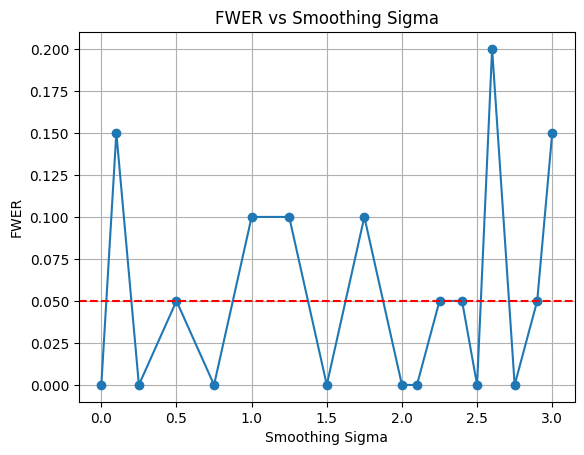

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# flatten fwer array
fwer = fwer_mat0.flatten()

# plot
plt.figure()
plt.plot(test_sigmas, fwer, marker='o')
plt.xlabel("Smoothing Sigma")
plt.ylabel("FWER")
plt.title("FWER vs Smoothing Sigma")
plt.grid(True)
plt.axhline(y=0.05, linestyle='--',color='r', label='Alpha = 0.05')
plt.show()

Results typically vary from 0.04 to 0.07, which is very reasonable. This is very close to the alpha = 0.05, and is a significant improvement over the non-controlled method.


# Performance Analysis: SNR, Smoothing, and "Net Utility"

In this section we are moving beyond just checking if the method is "safe" (controlling false positives). Now we want to know if it's actually **useful**. Can it find a signal if there is one?

We are running a **2-Parameter Sweep** changing two things at once: **Signal-to-Noise Ratio (SNR)** and **Smoothing ($\sigma$)**.


Here is an example of a simulated data with fake signal inserted:

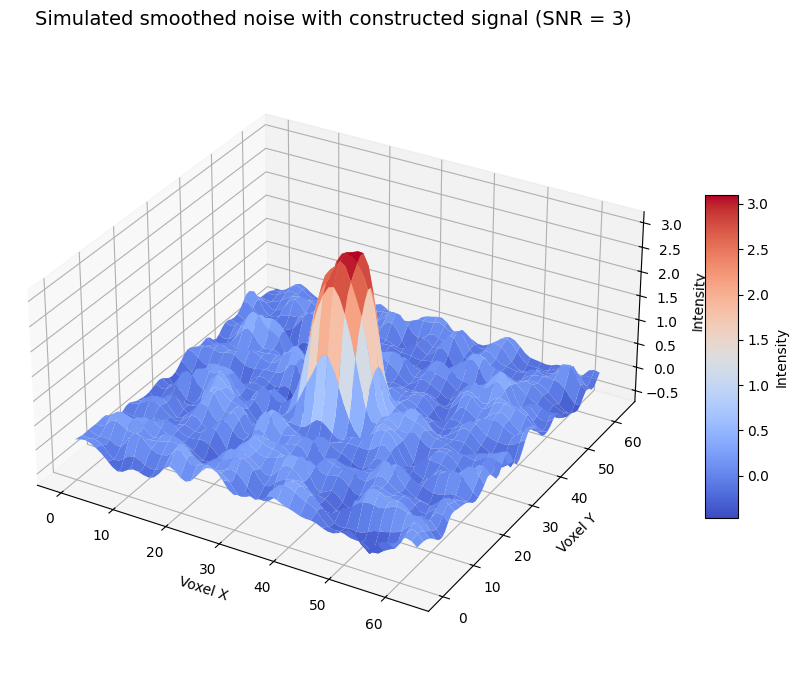

In [10]:
pl.plot_3d(hf.simulate_null_data(snr = 3, signal_radius=6, sigma = 1.5)[0], title="Simulated smoothed noise with constructed signal (SNR = 3)")

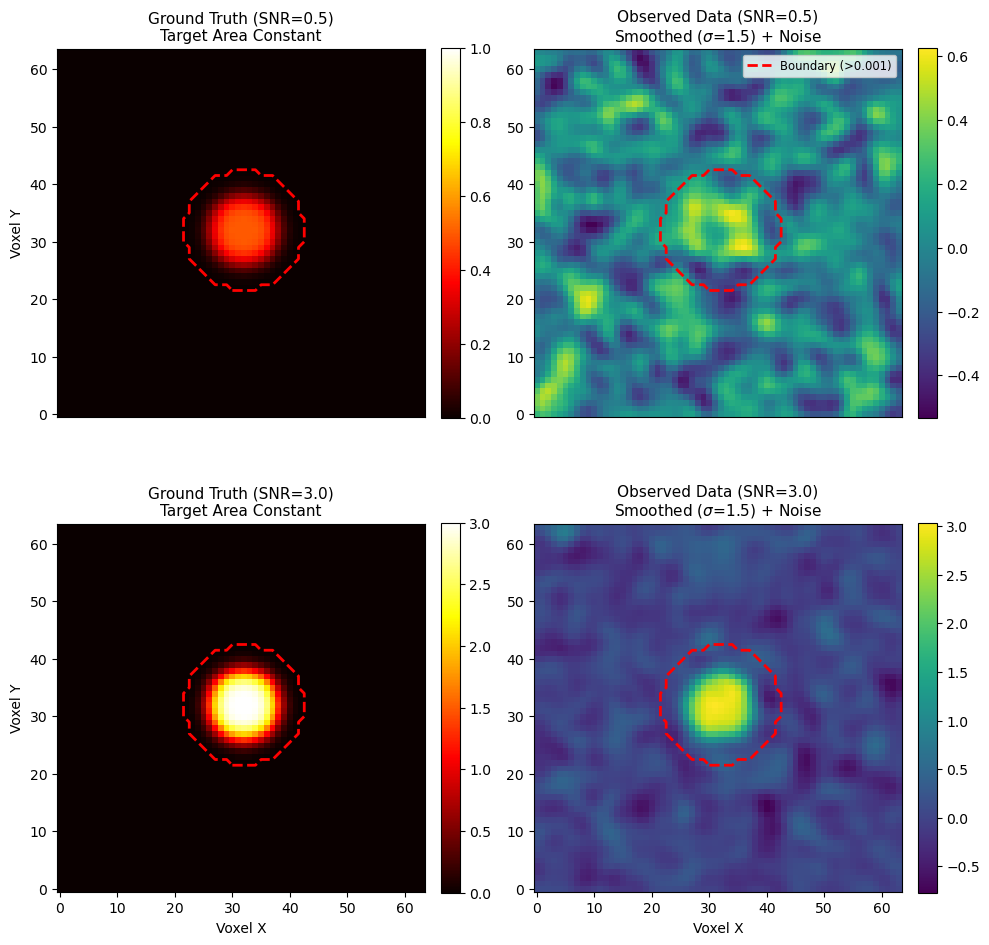

In [5]:
importlib.reload(pl)
pl.generate_multi_snr_viz(snr_list=[0.5, 3.0], null_boundary=0.001)

In [12]:
test_snrs =     [0, 0.1, 0.175, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.175, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] # Low smooth -> High smooth

# 2. Run Sweep
# n_runs=20 and n_perm=50 is LOW quality but fast
# High quality: n_runs=50, n_perm=100
sens_mat, fwer_mat = hf.run_2d_sweep(
    n_runs=20,          
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=6,
    n_perm=50,   
	null_boundary = null_boundary       
)

Starting 3D Sweep: 21 Sigmas x 21 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.175...
  > Processing Sigma = 0.4...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.6...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.1...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.4...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.6...
  > Processing Sigma = 2.75...
  > Processing Sigma = 2.9...
  > Processing Sigma = 3.0...
Sweep Complete.


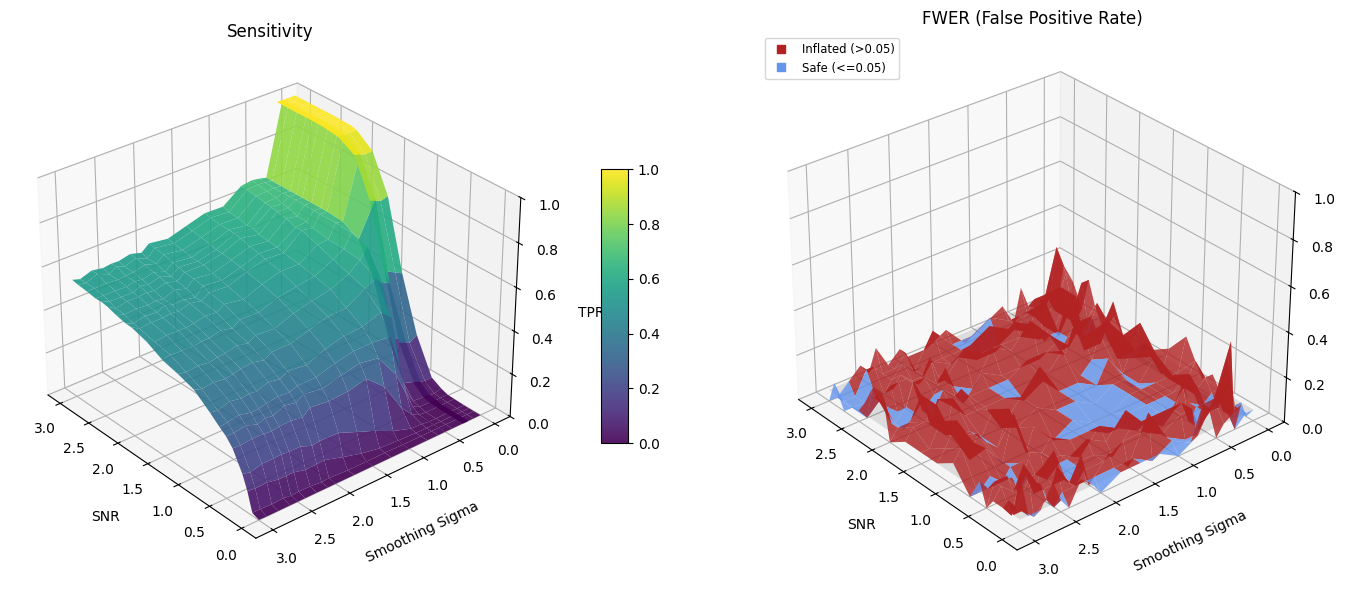

In [13]:
importlib.reload(pl)


pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)

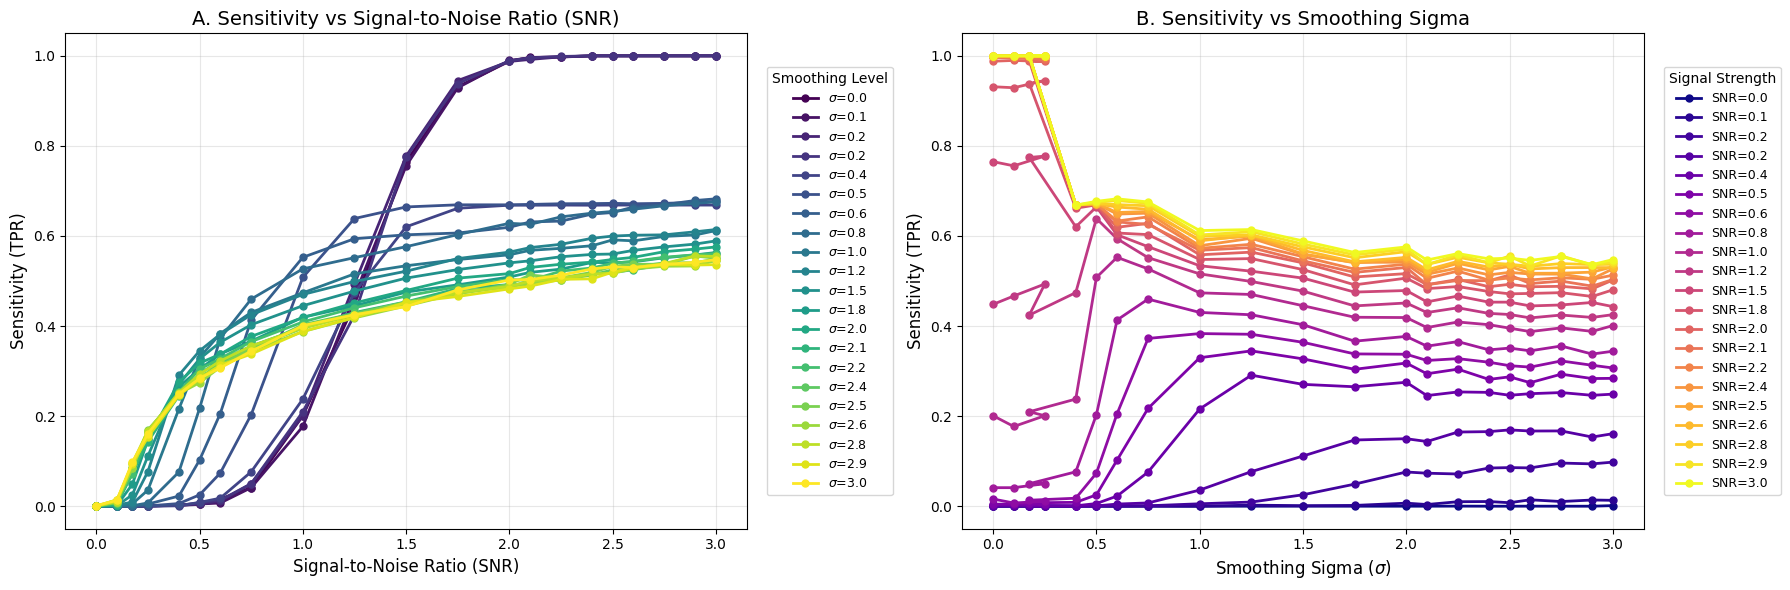

In [14]:
importlib.reload(pl)
pl.plot_sensitivity_analysis(test_snrs, test_sigmas, sens_mat)

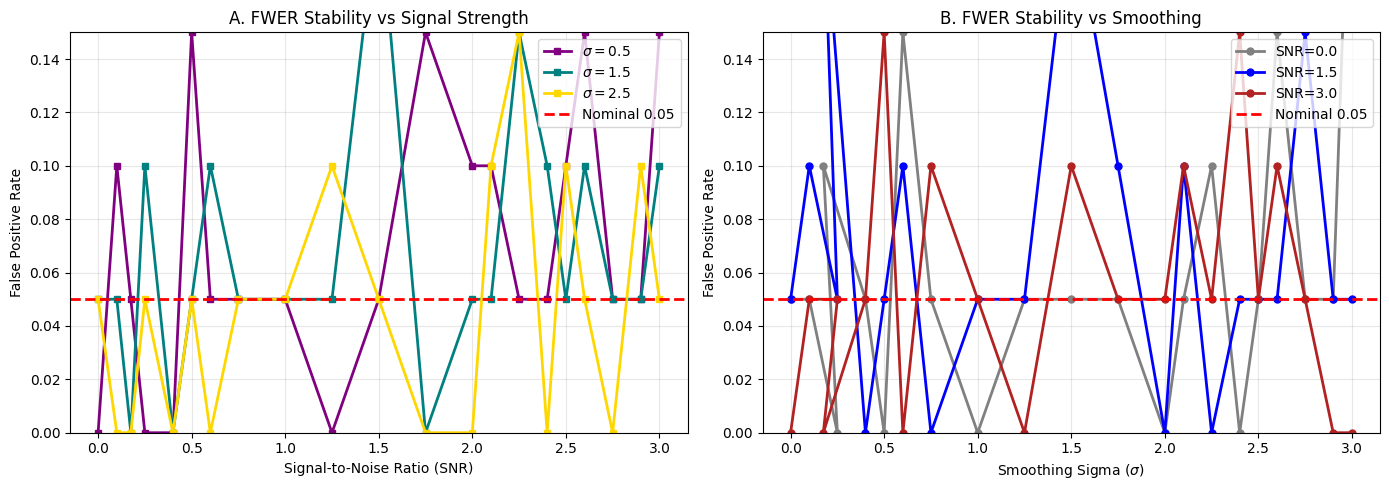

In [15]:

pl.plot_fwer_stability(test_snrs, test_sigmas, fwer_mat, np.array(test_sigmas), np.array(test_snrs))